In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

In [44]:

def read_xy_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Extract column labels from the second line (assumes fixed format)
    label_x, label_y = lines[1].replace('(labels "', "").replace('")', "").split('" "')

    data_blocks = {}
    current_label = None
    data_start = False

    for line in lines:
        line = line.strip()

        # Detect new data block
        if line.startswith("((xy/key/label"):
            current_label = line.split('"')[1]  # Extract label without regex
            data_blocks[current_label] = []
            data_start = True
            continue
        
        # Stop if end of data block
        if data_start and line.endswith(")"):
            continue
        
        # Read numerical data
        if data_start and line:
            values = line.split()
            data_blocks[current_label].append([float(values[0]), float(values[1])])

    # Convert blocks into DataFrames and merge
    merged_df = None
    for i, (key, data) in enumerate(data_blocks.items()):
        df = pd.DataFrame(data, columns=[label_x, key])  # Name the second column with block label
        if merged_df is None:
            merged_df = df
        else:
            merged_df = pd.merge(merged_df, df, on=label_x, how="outer")  # Merge on the first column

    
    return merged_df, label_x

In [45]:
def read_xy_file_stack_all(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Extract column labels from the second line (assumes fixed format)
    label_x, label_y = lines[1].replace('(labels "', "").replace('")', "").split('" "')

    data_blocks = {}
    current_label = None
    data_start = False

    for line in lines:
        line = line.strip()

        # Detect new data block
        if line.startswith("((xy/key/label"):
            current_label = line.split('"')[1]  # Extract label without regex
            data_blocks[current_label] = []
            data_start = True
            continue
        
        # Stop if end of data block
        if data_start and line.endswith(")"):
            continue
        
        # Read numerical data
        if data_start and line:
            values = line.split()
            data_blocks[current_label].append([float(values[0]), float(values[1])])

    # Convert blocks into DataFrames and concatenate
    concatenated_df = None
    for i, (key, data) in enumerate(data_blocks.items()):
        df = pd.DataFrame(data, columns=[label_x, key])  # Name the second column with block label
        if concatenated_df is None:
            concatenated_df = df
        else:
            concatenated_df = pd.concat([concatenated_df, df], axis=1)  # Concatenate horizontally

    return concatenated_df, label_x

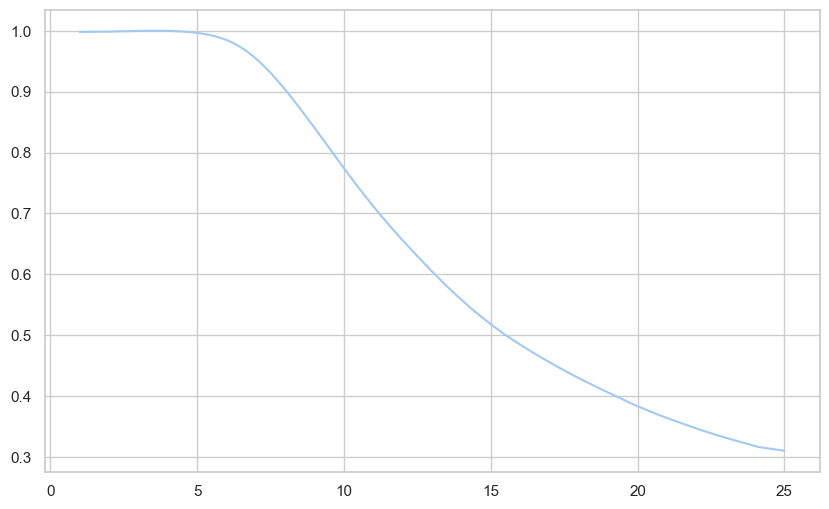

In [46]:
import pandas as pd
import re

def read_txt_file(file_path):
    # Read the file
    with open(file_path, "r") as f:
        lines = f.readlines()

    # Get the variable names
    variables = []
    dataframes = []
    current_zone = None
    data_block = []

    for line in lines:
        # Get variable names
        if "VARIABLES" in line:
            # Clean up the line to get variable names
            variables = [v.strip().strip('"') for v in line.split("=")[1].split(",")]

        # Detect new ZONE
        elif line.strip().startswith("ZONE"):
            if data_block:
                # Save previous data block
                df = pd.DataFrame(data_block, columns=[f"{v}_{current_zone}" for v in variables])
                dataframes.append(df)
                data_block = []

            # Extract zone identifier
            match = re.search(r'x/Dj\s*=\s*(\d+)', line)
            if match:
                current_zone = f"x{match.group(1)}"

        # Parse data lines
        elif re.match(r"^[\d\.\-\+E]+", line.strip()):
            nums = list(map(float, line.strip().split()))
            data_block.append(nums)

    # Don't forget the last block
    if data_block:
        df = pd.DataFrame(data_block, columns=[f"{v}_{current_zone}" for v in variables])
        dataframes.append(df)

    # Combine all zone-specific data horizontally
    final_df = pd.concat(dataframes, axis=1)

    # Optionally save or inspect
    # final_df.to_csv("jet_data_combined.csv", index=False)
    return final_df

file = r'exercise9/jet-nasa-data.txt'
file2= r'exercise9/jet-nasa-data-axis.txt'
df_nasa = read_txt_file(file)
df_nasa_axis = read_txt_file(file2)
df_nasa
plt.figure(figsize=(10, 6))
plt.plot(df_nasa_axis['x/Dj_None'],df_nasa_axis['u/Uj_None'],  label='Zone 1')

In [47]:
import pandas as pd
import re

with open("exercise9/turb1-y-over-d-jet-k-over-u-jet2.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"{label1}_{key}", f"{label2}_{key}"])
    dfs.append(df)



# Combine into one dataframe, aligning rows
final_df = pd.concat(dfs, axis=1)

# Show or save
final_df


,k-over-u-jet2_x-10d,y-over-d-jet_x-10d,k-over-u-jet2_x-15d,y-over-d-jet_x-15d,k-over-u-jet2_x-20d,y-over-d-jet_x-20d,k-over-u-jet2_x-2d,y-over-d-jet_x-2d,k-over-u-jet2_x-5d,y-over-d-jet_x-5d
0,0.007324,1.500000e+00,0.010684,1.500000e+00,0.008188,1.500000e+00,4.990490e-06,1.164150e-10,4.725120e-06,1.346050e-10
1,0.008113,1.457400e+00,0.010900,1.476960e+00,0.008198,1.496520e+00,4.990690e-06,3.023070e-03,4.725230e-06,3.023070e-03
2,0.009309,1.396140e+00,0.011475,1.414450e+00,0.008370,1.432750e+00,4.991390e-06,6.358480e-03,4.725590e-06,6.358480e-03
3,0.010482,1.338610e+00,0.012003,1.355740e+00,0.008521,1.372870e+00,4.992580e-06,9.693900e-03,4.726220e-06,9.693900e-03
4,0.011623,1.284570e+00,0.012485,1.300600e+00,0.008651,1.316630e+00,4.994220e-06,1.302930e-02,4.727090e-06,1.302930e-02
...,...,...,...,...,...,...,...,...,...,...
196,0.020667,9.693900e-03,0.015734,9.693900e-03,0.009296,9.693900e-03,6.220030e-07,1.311200e+00,1.041450e-05,1.321470e+00
197,0.020658,6.358480e-03,0.015734,6.358480e-03,0.009296,6.358480e-03,5.893660e-07,1.366850e+00,8.515120e-07,1.377830e+00
198,0.020653,3.023070e-03,0.015734,3.023070e-03,0.009296,3.023070e-03,5.598520e-07,1.426110e+00,5.823230e-07,1.437850e+00
199,0.020651,8.731150e-11,0.015734,1.164150e-10,0.009296,8.276400e-11,5.332040e-07,1.489210e+00,5.458520e-07,1.500000e+00


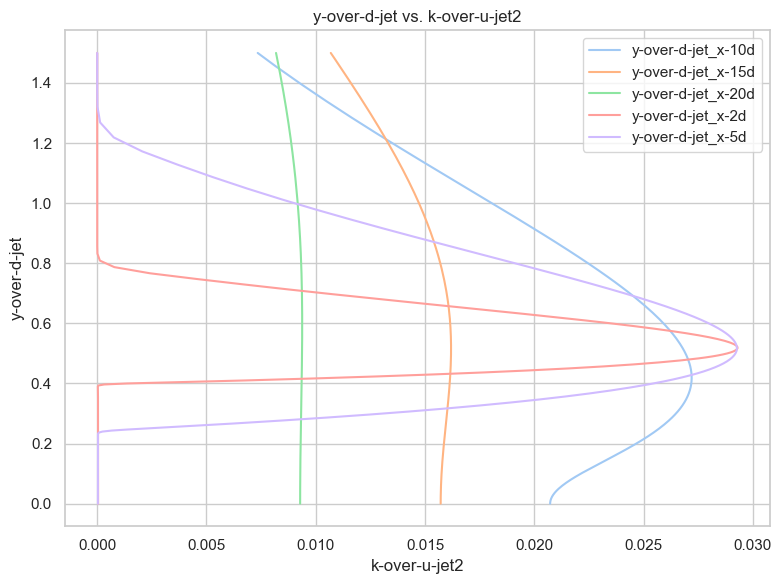

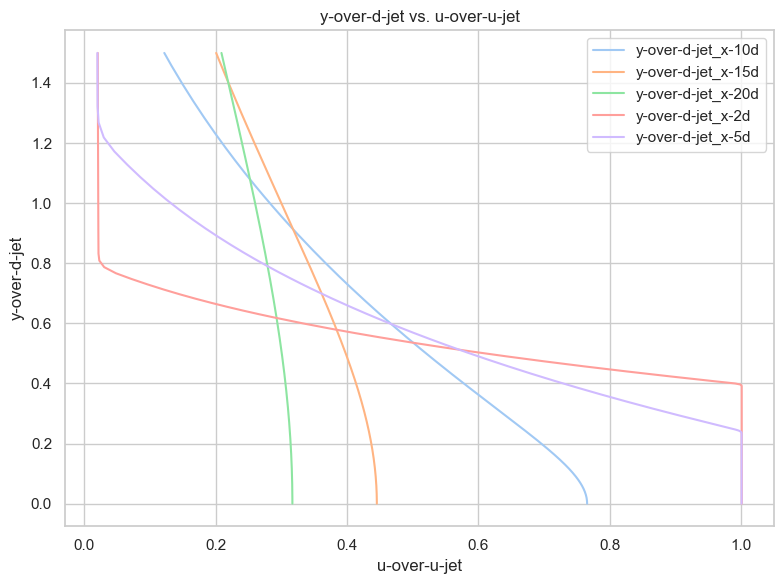

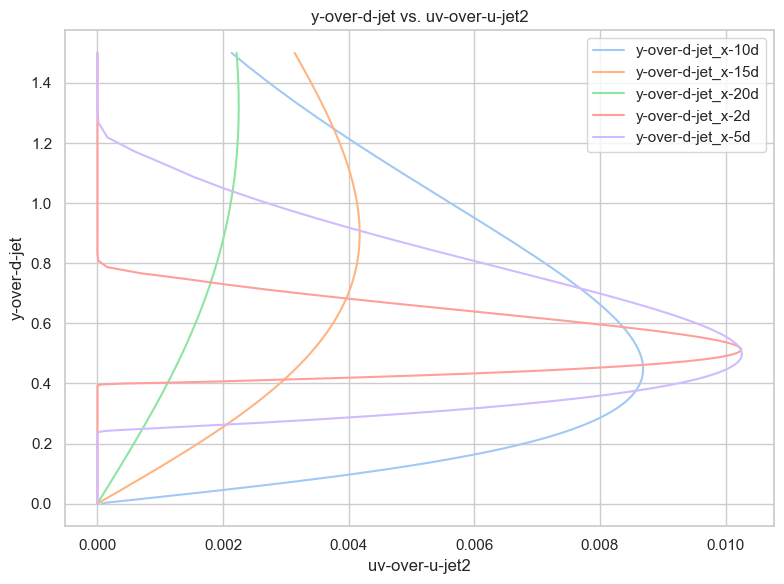

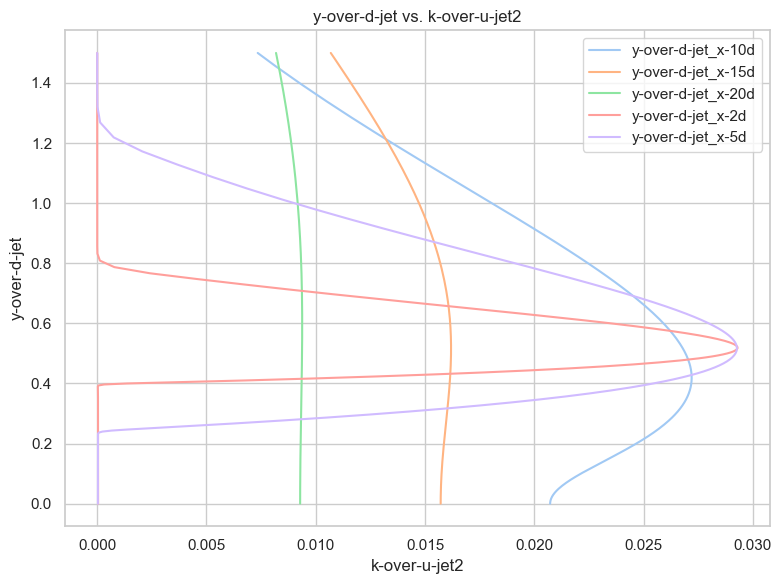

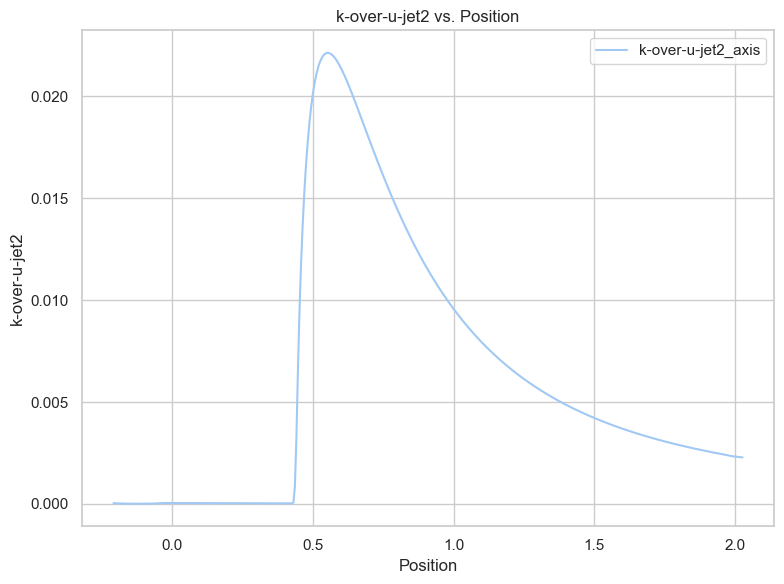

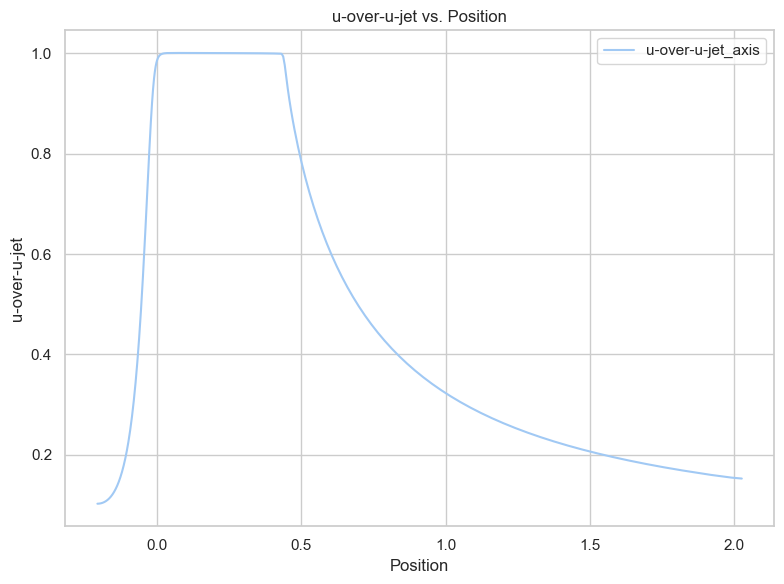

,Position_axis,u-over-u-jet_axis
0,2.025650,0.152506
1,1.989580,0.154411
2,1.954210,0.157135
3,1.919530,0.159745
4,1.885520,0.162744
...,...,...
596,-0.203636,0.102392
597,-0.204324,0.102373
598,-0.205012,0.102360
599,-0.205700,0.102351


In [48]:
#TURBULENT JET DATA - 1% TURBULENCE 

from os import read
import pandas as pd
import matplotlib.pyplot as plt
import re


def reading_jet_file(FILE):
# === READ AND PARSE THE DATA FILE ===
    with open(FILE, "r") as f:
        content = f.read()

    # Extract labels
    labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
    if labels_match:
        label1, label2 = labels_match.groups()
    else:
        raise ValueError("Could not find labels.")

    # Extract each data block with its key/label
    blocks = re.findall(
        r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
        content
    )

    dfs = []
    for key, data_block in blocks:
        # Convert string block to list of [x, y]
        data = [
            list(map(float, line.strip().split()))
            for line in data_block.strip().splitlines()
            if line.strip()
        ]
        df = pd.DataFrame(data, columns=[f"{label1}_{key}", f"{label2}_{key}"])
        dfs.append(df)

    # Combine into one dataframe, aligning rows
    final_df1 = pd.concat(dfs, axis=1)

    # === PLOTTING ===
    plt.figure(figsize=(8, 6))
    for df in dfs:
        x_col = df.columns[0]
        y_col = df.columns[1]
        plt.plot(df[x_col], df[y_col], label=y_col)

    plt.xlabel(label1)
    plt.ylabel(label2)
    plt.title(f"{label2} vs. {label1}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


    return final_df1

reading_jet_file("exercise9/turb5-y-over-d-jet-k-over-u-jet2.xy")
reading_jet_file('exercise9/turb5-y-over-d-jet-u-over-u-jet.xy')
reading_jet_file('exercise9/turb5-y-over-d-jet-uv-over-u-jet2.xy')
reading_jet_file("exercise9/turb5-y-over-d-jet-k-over-u-jet2.xy")
reading_jet_file("exercise9/turb5-k-over-u-jet2-over-x-over-d-jet.xy")
reading_jet_file("exercise9/turb5-u-over-u-jet-over-x-over-d-jet.xy")


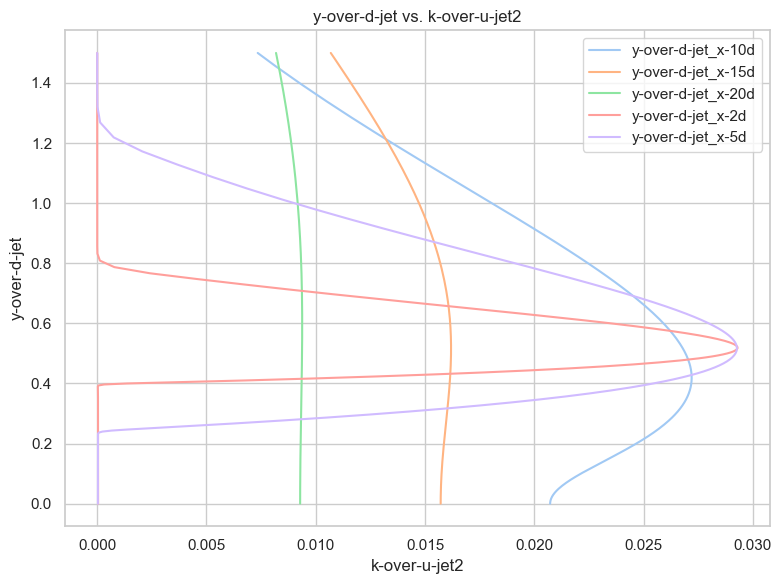

In [49]:
#TURBULENT JET DATA - 1% TURBULENCE 

import pandas as pd
import matplotlib.pyplot as plt
import re

# === READ AND PARSE THE DATA FILE ===
with open("exercise9/turb5-y-over-d-jet-k-over-u-jet2.xy", "r") as f:
    content = f.read()

# Extract labels
labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
if labels_match:
    label1, label2 = labels_match.groups()
else:
    raise ValueError("Could not find labels.")

# Extract each data block with its key/label
blocks = re.findall(
    r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
    content
)

dfs = []
for key, data_block in blocks:
    # Convert string block to list of [x, y]
    data = [
        list(map(float, line.strip().split()))
        for line in data_block.strip().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(data, columns=[f"{label1}_{key}", f"{label2}_{key}"])
    dfs.append(df)

# Combine into one dataframe, aligning rows
final_df = pd.concat(dfs, axis=1)

# === PLOTTING ===
plt.figure(figsize=(8, 6))
for df in dfs:
    x_col = df.columns[0]
    y_col = df.columns[1]
    plt.plot(df[x_col], df[y_col], label=y_col)

plt.xlabel(label1)
plt.ylabel(label2)
plt.title(f"{label2} vs. {label1}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


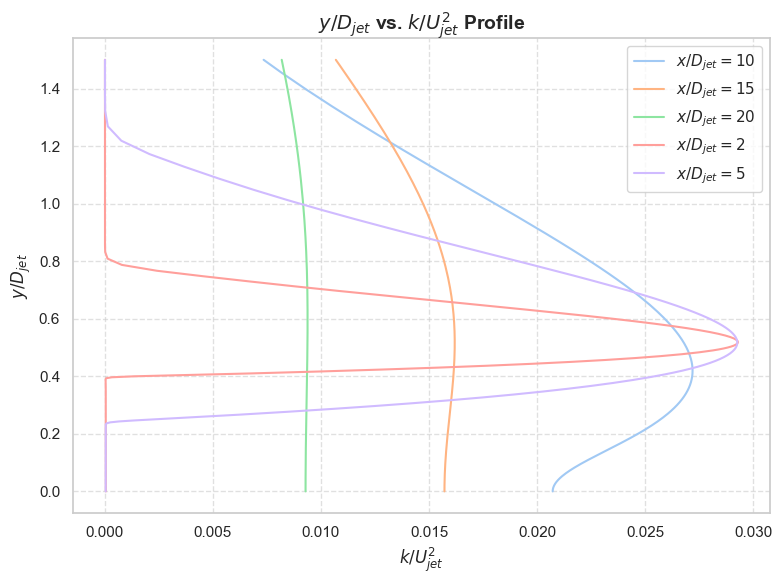

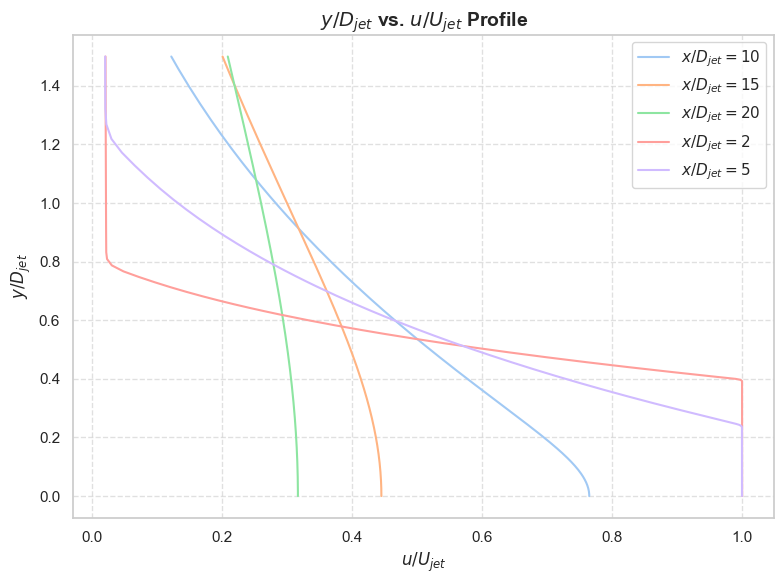

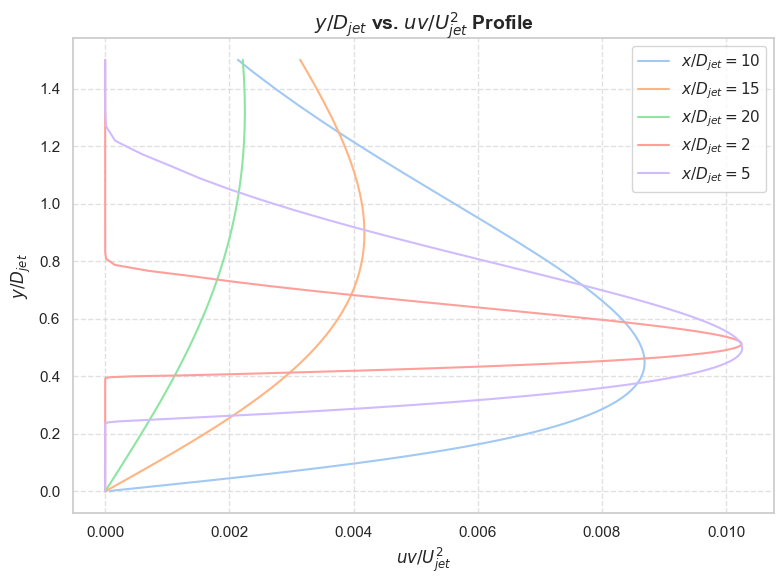

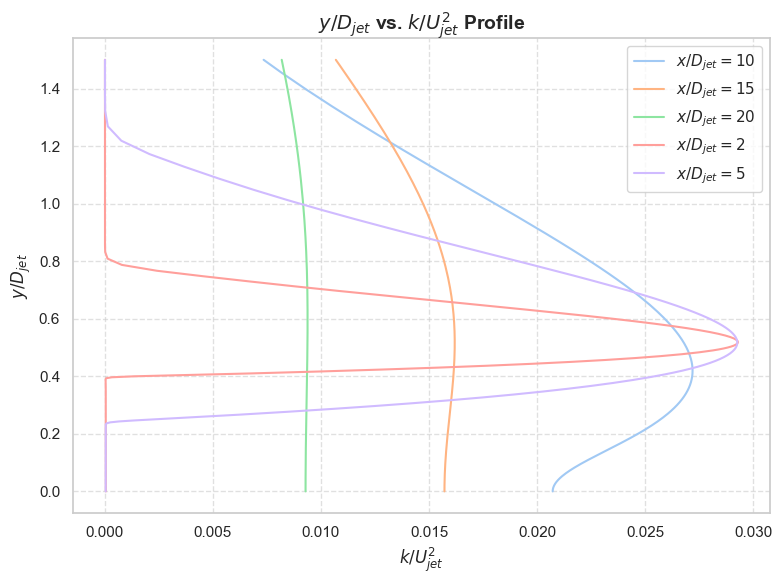

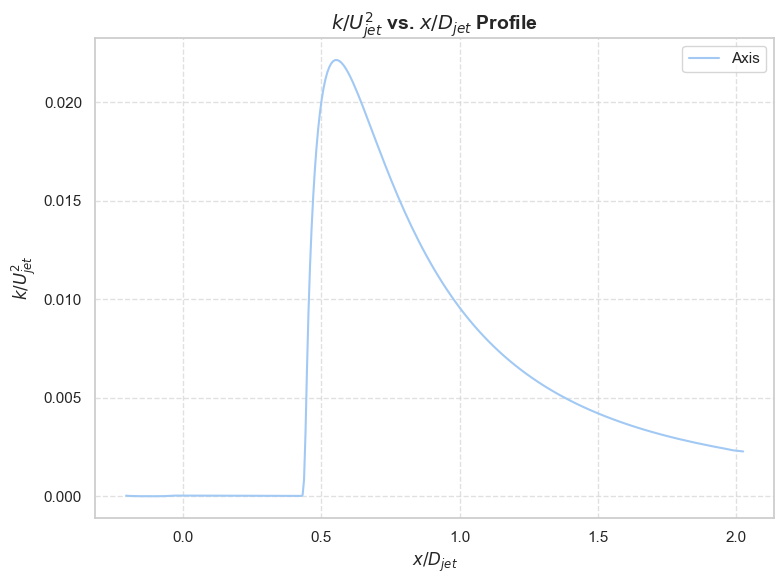

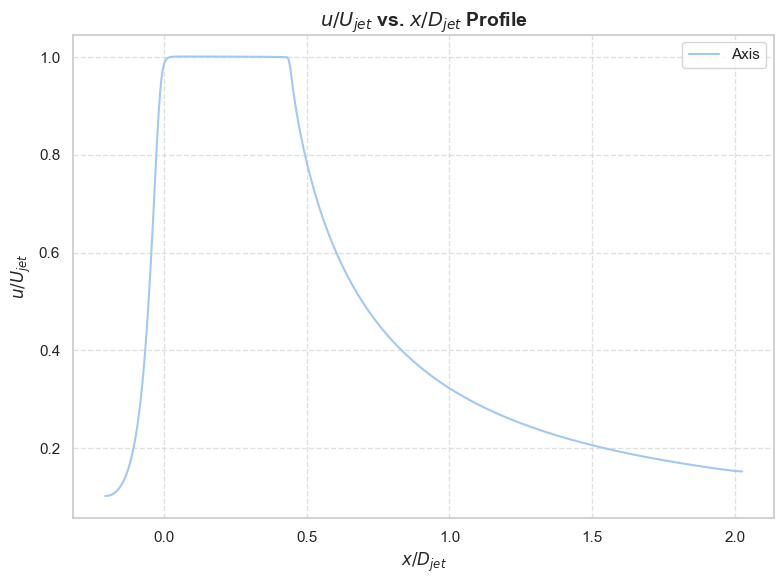

,Position_axis,u-over-u-jet_axis
0,2.025650,0.152506
1,1.989580,0.154411
2,1.954210,0.157135
3,1.919530,0.159745
4,1.885520,0.162744
...,...,...
596,-0.203636,0.102392
597,-0.204324,0.102373
598,-0.205012,0.102360
599,-0.205700,0.102351


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import re


def reading_jet_file1(
    FILE,
    xlabel=None,
    ylabel=None,
    title=None,
    legend_labels=None,
    figsize=(8, 6),
    style_kwargs=None  # Optional dict for line style customization
):
    with open(FILE, "r") as f:
        content = f.read()

    # Extract labels from file
    labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
    if labels_match:
        label1, label2 = labels_match.groups()
    else:
        raise ValueError("Could not find labels.")

    # Use custom labels if provided
    xlabel = xlabel or label1
    ylabel = ylabel or label2
    title = title or f"{ylabel} vs. {xlabel}"

    # Extract each data block with its key/label
    blocks = re.findall(
        r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
        content
    )

    dfs = []
    keys = []
    for key, data_block in blocks:
        keys.append(key)
        data = [
            list(map(float, line.strip().split()))
            for line in data_block.strip().splitlines()
            if line.strip()
        ]
        df = pd.DataFrame(data, columns=[f"{label1}_{key}", f"{label2}_{key}"])
        dfs.append(df)

    final_df = pd.concat(dfs, axis=1)

    # === PLOTTING ===
    plt.figure(figsize=figsize)
    for i, df in enumerate(dfs):
        x_col = df.columns[0]
        y_col = df.columns[1]
        label = legend_labels[i] if legend_labels and i < len(legend_labels) else y_col

        # Apply custom styling if provided
        if style_kwargs:
            plt.plot(df[x_col], df[y_col], label=label, **style_kwargs)
        else:
            plt.plot(df[x_col], df[y_col], label=label)

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return final_df


reading_jet_file1(FILE="exercise9/turb5-y-over-d-jet-k-over-u-jet2.xy", 
                  xlabel=r'$k/U_{jet}^2$', ylabel=r'$y/D_{jet}$', title=r'$y/D_{jet}$ vs. $k/U_{jet}^2$ Profile',
                  legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'])
reading_jet_file1('exercise9/turb5-y-over-d-jet-u-over-u-jet.xy', r'$u/U_{jet}$', r'$y/D_{jet}$', r'$y/D_{jet}$ vs. $u/U_{jet}$ Profile',
                  [r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'])
reading_jet_file1('exercise9/turb5-y-over-d-jet-uv-over-u-jet2.xy', r'$uv/U_{jet}^2$', r'$y/D_{jet}$', r'$y/D_{jet}$ vs. $uv/U_{jet}^2$ Profile',
                  [r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'])


reading_jet_file1("exercise9/turb5-y-over-d-jet-k-over-u-jet2.xy", r'$k/U_{jet}^2$', r'$y/D_{jet}$', r'$y/D_{jet}$ vs. $k/U_{jet}^2$ Profile',
                  [r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'])


reading_jet_file1("exercise9/turb5-k-over-u-jet2-over-x-over-d-jet.xy", r'$x/D_{jet}$',r'$k/U_{jet}^2$',  r'$k/U_{jet}^2$ vs. $x/D_{jet}$ Profile',
                  [r'Axis'])
reading_jet_file1("exercise9/turb5-u-over-u-jet-over-x-over-d-jet.xy", r'$x/D_{jet}$',r'$u/U_{jet}$',  r'$u/U_{jet}$ vs. $x/D_{jet}$ Profile',
                  [r'Axis'])


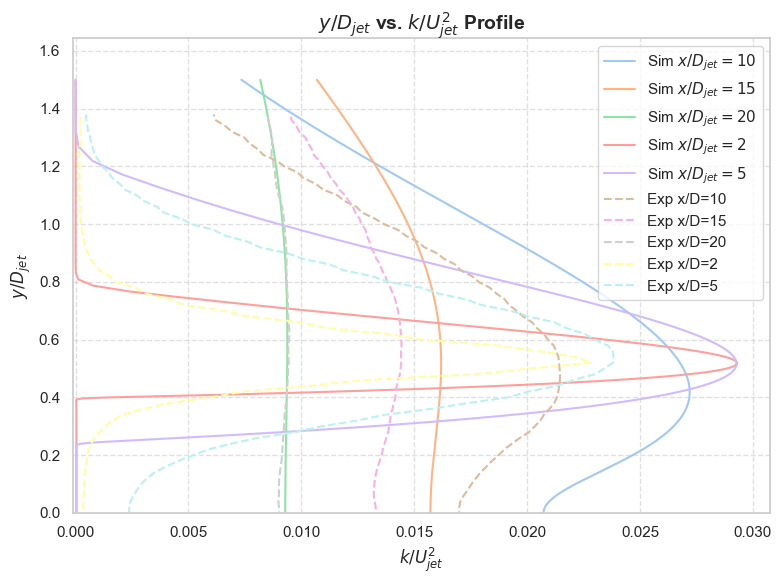

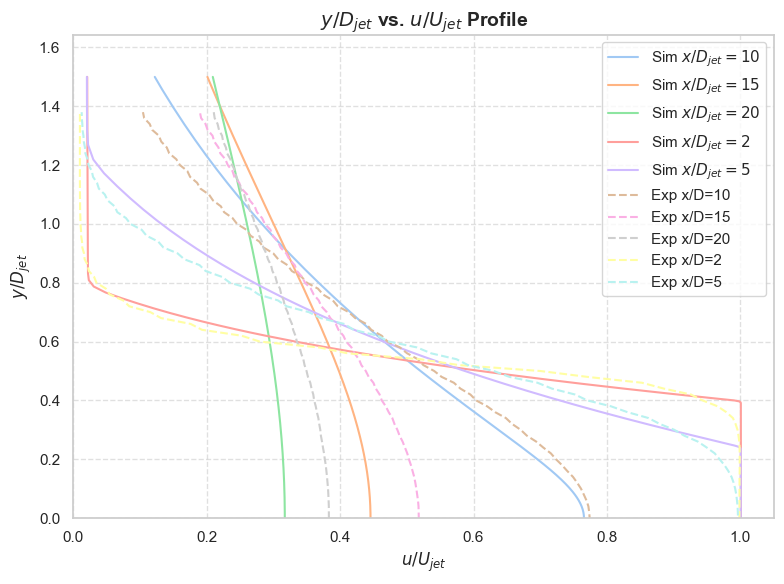

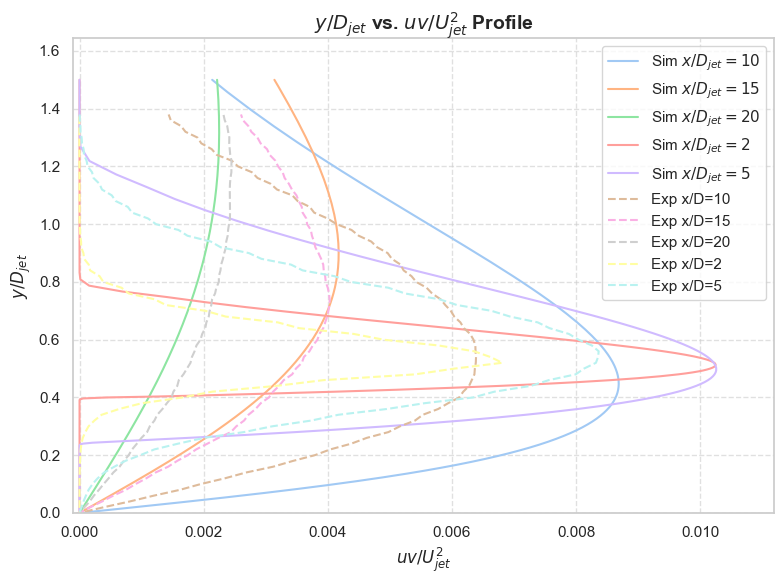

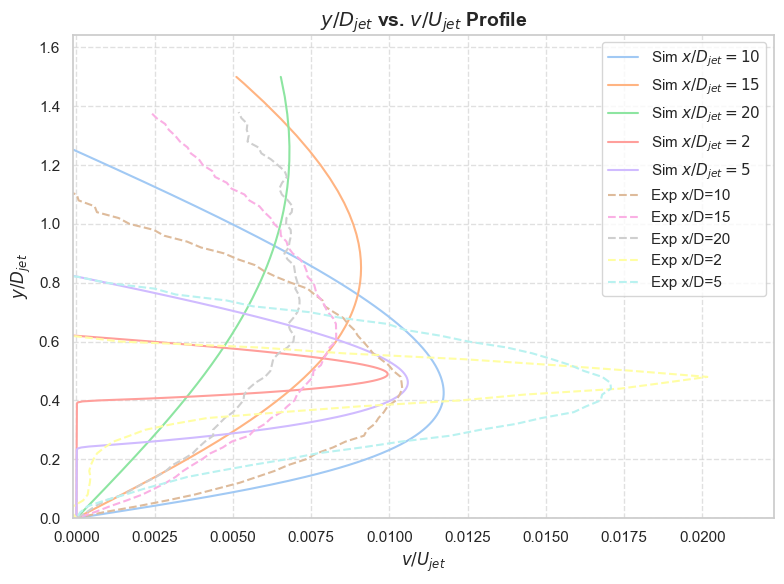

'<3'

In [51]:
def reading_jet_file_nasa(
    FILE,
    xlabel=None,
    ylabel=None,
    title=None,
    legend_labels=None,
    style_kwargs=None,
    data_nasa=None,  # Pass your experimental dataframe here
    nasa_quantity_y=None,  # e.g., "k/Uj^2"
    nasa_quantity_x=None,
    nasa_style=None,  # e.g., {"marker": "s", "linestyle": "None"}
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import re

    # === READ SIMULATION DATA ===
    with open(FILE, "r") as f:
        content = f.read()

    labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
    if labels_match:
        label1, label2 = labels_match.groups()
    else:
        raise ValueError("Could not find labels.")

    xlabel = xlabel or label1
    ylabel = ylabel or label2
    title = title or f"{ylabel} vs. {xlabel}"

    blocks = re.findall(
        r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
        content
    )

    dfs = []
    keys = []
    for key, data_block in blocks:
        keys.append(key)
        data = [
            list(map(float, line.strip().split()))
            for line in data_block.strip().splitlines()
            if line.strip()
        ]
        df = pd.DataFrame(data, columns=[f"{label1}_{key}", f"{label2}_{key}"])
        dfs.append(df)

    final_df = pd.concat(dfs, axis=1)

    # === PLOTTING ===
    plt.figure(figsize=(8, 6))
    
    # Plot simulation data
    for i, df in enumerate(dfs):
        x_col = df.columns[0]
        y_col = df.columns[1]
        label = legend_labels[i] if legend_labels and i < len(legend_labels) else y_col

        if style_kwargs:
            plt.plot(df[x_col], df[y_col], label=f"Sim {label}", **style_kwargs)
        else:
            plt.plot(df[x_col], df[y_col], label=f"Sim {label}")

    # Plot experimental NASA data
    if data_nasa is not None and nasa_quantity_x and nasa_quantity_y is not None:
        for x_loc in [10, 15, 20, 2, 5]:  # You can change these as needed
            x_col = f"{nasa_quantity_x}_x{x_loc}"
            y_col = f"{nasa_quantity_y}_x{x_loc}"
            if x_col in data_nasa.columns and y_col in data_nasa.columns:
                plt.plot(
                    data_nasa[x_col],
                    data_nasa[y_col],
                    label=f"Exp x/D={x_loc}",
                    **(nasa_style if nasa_style else {"marker": None, "linestyle": "--"})
                )

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(left=-0.0001)  # Set x-axis limit to start from 0
    plt.ylim(bottom=0)  # Set y-axis limit to start from 0
    plt.legend()
    plt.tight_layout()
    plt.show()

    return '<3'



def reading_jet_FILES_nasa(
    FILE1,
    FILE2,
    xlabel=None,
    ylabel=None,
    title=None,
    legend_labels=None,
    style_kwargs=None,
    data_nasa=None,  # Pass your experimental dataframe here
    nasa_quantity_y=None,  # e.g., "k/Uj^2"
    nasa_quantity_x=None,
    nasa_style=None,  # e.g., {"marker": "s", "linestyle": "None"}
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import re

    # === READ SIMULATION DATA ===

    with open(FILE1, "r") as f:
        content = f.read()

    labels_match1 = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
    if labels_match1:
        label1, label2 = labels_match1.groups()
    else:
        raise ValueError("Could not find labels.")

    xlabel = xlabel or label1
    ylabel = ylabel or label2
    title = title or f"{ylabel} vs. {xlabel}"

    blocks = re.findall(
        r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
        content
    )

    dfs1 = []
    keys1 = []
    for key, data_block in blocks:
        keys1.append(key)
        data = [
            list(map(float, line.strip().split()))
            for line in data_block.strip().splitlines()
            if line.strip()
        ]
        df = pd.DataFrame(data, columns=[f"{label1}_{key}", f"{label2}_{key}"])
        dfs1.append(df)

    final_df1 = pd.concat(dfs1, axis=1)

    # === PLOTTING ===
    plt.figure(figsize=(8, 6))
    
    # Plot simulation data
    for i, df in enumerate(dfs1):
        x_col = df.columns[0]
        y_col = df.columns[1]
        label = legend_labels[i] if legend_labels and i < len(legend_labels) else y_col

        if style_kwargs:
            plt.plot(df[x_col], df[y_col], label=f"2-eq {label}", **style_kwargs)
        else:
            plt.plot(df[x_col], df[y_col], label=f"2-eq {label}")

    # Plot experimental NASA data
    if data_nasa is not None and nasa_quantity_x and nasa_quantity_y is not None:
        for x_loc in [10, 15, 20, 2, 5]:  # You can change these as needed
            x_col = f"{nasa_quantity_x}_x{x_loc}"
            y_col = f"{nasa_quantity_y}_x{x_loc}"
            if x_col in data_nasa.columns and y_col in data_nasa.columns:
                plt.plot(
                    data_nasa[x_col],
                    data_nasa[y_col],
                    label=f"Exp x/D={x_loc}",
                    **(nasa_style if nasa_style else {"marker": None, "linestyle": "--"})
                )

    with open(FILE2, "r") as f:
        content = f.read()

    labels_match2 = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
    if labels_match2:
        label1, label2 = labels_match2.groups()
    else:
        raise ValueError("Could not find labels.")

    xlabel = xlabel or label1
    ylabel = ylabel or label2
    title = title or f"{ylabel} vs. {xlabel}"

    blocks = re.findall(
        r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
        content
    )

    dfs2 = []
    keys2 = []
    for key, data_block in blocks:
        keys2.append(key)
        data = [
            list(map(float, line.strip().split()))
            for line in data_block.strip().splitlines()
            if line.strip()
        ]
        df = pd.DataFrame(data, columns=[f"{label1}_{key}", f"{label2}_{key}"])
        dfs2.append(df)

    final_df2 = pd.concat(dfs2, axis=1)

    import seaborn as sns
    # Set seaborn style
    sns.set_theme(style="whitegrid")
    

    # Plot simulation data
    for i, dfr in enumerate(dfs2):
        x_col = dfr.columns[0]
        y_col = dfr.columns[1]
        label = legend_labels[i] if legend_labels and i < len(legend_labels) else y_col

        if style_kwargs:
            plt.plot(dfr[x_col], dfr[y_col], color=sns.set_theme(style='whitegrid'), label=f"1-eq {label}", **style_kwargs)
        else:
            plt.plot(dfr[x_col], dfr[y_col], color=sns.set_theme(style='whitegrid'), label=f"1-eq {label}")


    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(left=-0.0001)  # Set x-axis limit to start from 0
    plt.ylim(bottom=0)  # Set y-axis limit to start from 0
    plt.legend()
    plt.tight_layout()
    plt.show()

    return '<3'

def reading_jet_file_nasa_axis(
    FILE,
    xlabel=None,
    ylabel=None,
    title=None,
    legend_labels=None,
    style_kwargs=None,
    data_nasa=None,  # Pass your experimental dataframe here
    nasa_quantity_y=None,  # e.g., "k/Uj^2"
    nasa_quantity_x=None,
    nasa_style=None,  # e.g., {"marker": "s", "linestyle": "None"}
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import re

    # === READ SIMULATION DATA ===
    with open(FILE, "r") as f:
        content = f.read()

    labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
    if labels_match:
        label1, label2 = labels_match.groups()
    else:
        raise ValueError("Could not find labels.")

    xlabel = xlabel or label1
    ylabel = ylabel or label2
    title = title or f"{ylabel} vs. {xlabel}"

    blocks = re.findall(
        r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
        content
    )

    dfs = []
    keys = []
    for key, data_block in blocks:
        keys.append(key)
        data = [
            list(map(float, line.strip().split()))
            for line in data_block.strip().splitlines()
            if line.strip()
        ]
        df = pd.DataFrame(data, columns=[f"{label1}_{key}", f"{label2}_{key}"])
        dfs.append(df)

    final_df = pd.concat(dfs, axis=1)

    # === PLOTTING ===
    plt.figure(figsize=(8, 6))
    
    # Plot simulation data
    for i, df in enumerate(dfs):
        x_col = df.columns[0]
        y_col = df.columns[1]
        label = legend_labels[i] if legend_labels and i < len(legend_labels) else y_col

        if style_kwargs:
            plt.plot(df[x_col], df[y_col], label=f"Sim {label}", **style_kwargs)
        else:
            plt.plot(df[x_col], df[y_col], label=f"Sim {label}")

    # Plot experimental NASA data
    if data_nasa is not None and nasa_quantity_x and nasa_quantity_y is not None:
        for x_loc in [None]:  # You can change these as needed
            x_col = f"{nasa_quantity_x}_{x_loc}"
            y_col = f"{nasa_quantity_y}_{x_loc}"
            if x_col in data_nasa.columns and y_col in data_nasa.columns:
                plt.plot(
                    data_nasa[x_col],
                    data_nasa[y_col],
                    label=f"Exp {x_loc}",
                    **(nasa_style if nasa_style else {"marker": None, "linestyle": "--"})
                )

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(left=-0.0001)  # Set x-axis limit to start from 0
    plt.ylim(bottom=0)  # Set y-axis limit to start from 0
    plt.legend()
    plt.tight_layout()
    plt.show()

    return '<3'

reading_jet_file_nasa(
    FILE="exercise9/turb5-y-over-d-jet-k-over-u-jet2.xy",
    xlabel=r'$k/U_{jet}^2$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $k/U_{jet}^2$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="k/Uj^2",
    nasa_style={"marker": "None", "linestyle": "--"}
)	

reading_jet_file_nasa(
    FILE="exercise9/turb5-y-over-d-jet-u-over-u-jet.xy",
    xlabel=r'$u/U_{jet}$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $u/U_{jet}$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="u/Uj",
    nasa_style={"marker": "None", "linestyle": "--"}
)

reading_jet_file_nasa(
    FILE="exercise9/turb5-y-over-d-jet-uv-over-u-jet2.xy",
    xlabel=r'$uv/U_{jet}^2$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $uv/U_{jet}^2$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="u'v'/Uj^2",
    nasa_style={"marker": "None", "linestyle": "--"}
)


reading_jet_file_nasa(
    FILE="exercise9/turb5-y-over-d-jet-v-over-u-jet.xy",
    xlabel=r'$v/U_{jet}$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $v/U_{jet}$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="v/Uj",
    nasa_style={"marker": "None", "linestyle": "--"}
)



#changed data-frame

#reading_jet_file_nasa_axis(
#    FILE="exercise9/turb5-k-over-u-jet2-over-x-over-d-jet.xy",
#    xlabel=r'$x/D_{jet}$',
#    ylabel=r'$k/U_{jet}^2$',
#    title=r'$k/U_{jet}^2$ vs. $x/D_{jet}$ Profile',
#    legend_labels=[r'Axis'],
#    data_nasa=None,
#    nasa_quantity_y='k/Uj^2',
#    nasa_quantity_x="x/Dj",
#    nasa_style={"marker": "None", "linestyle": "--"}
#)

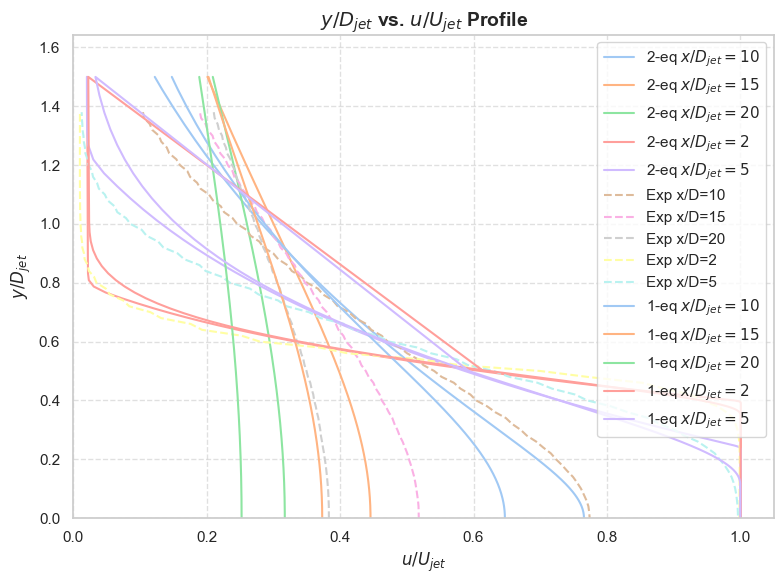

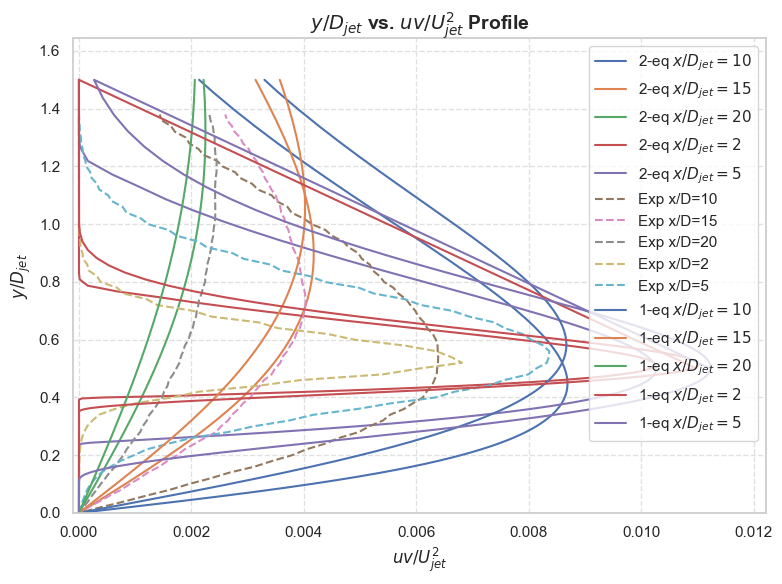

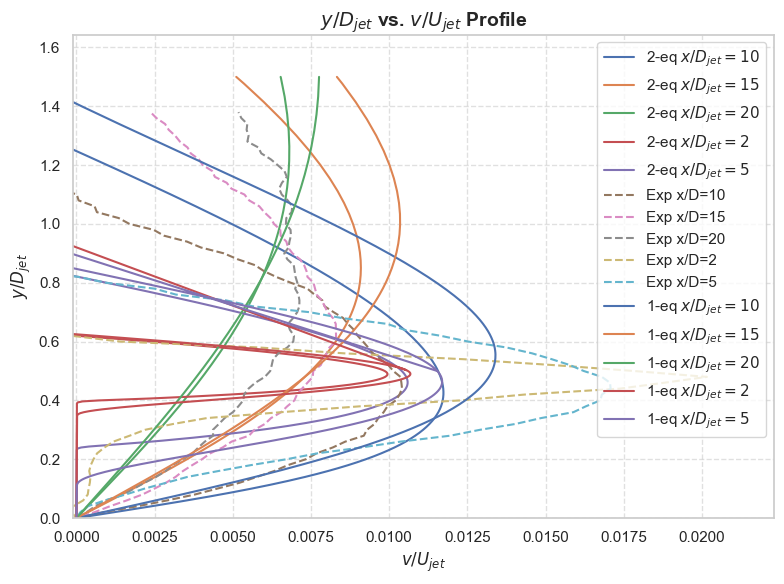

'<3'

In [52]:

reading_jet_FILES_nasa(
    FILE1="exercise9/turb5-y-over-d-jet-u-over-u-jet.xy",
    FILE2="exercise9/sa-turb5-y-over-d-jet-u-over-u-jet",
    xlabel=r'$u/U_{jet}$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $u/U_{jet}$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="u/Uj",
    nasa_style={"marker": "None", "linestyle": "--"}
)

reading_jet_FILES_nasa(
    FILE1="exercise9/turb5-y-over-d-jet-uv-over-u-jet2.xy",
    FILE2="exercise9/sa-turb5-y-over-d-jet-uv-over-u-jet2.xy",
    xlabel=r'$uv/U_{jet}^2$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $uv/U_{jet}^2$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="u'v'/Uj^2",
    nasa_style={"marker": "None", "linestyle": "--"}
)


reading_jet_FILES_nasa(
    FILE1="exercise9/turb5-y-over-d-jet-v-over-u-jet.xy",
    FILE2="exercise9/sa-turb5-y-over-d-jet-v-over-u-jet.xy",
    xlabel=r'$v/U_{jet}$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $v/U_{jet}$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="v/Uj",
    nasa_style={"marker": "None", "linestyle": "--"}
)


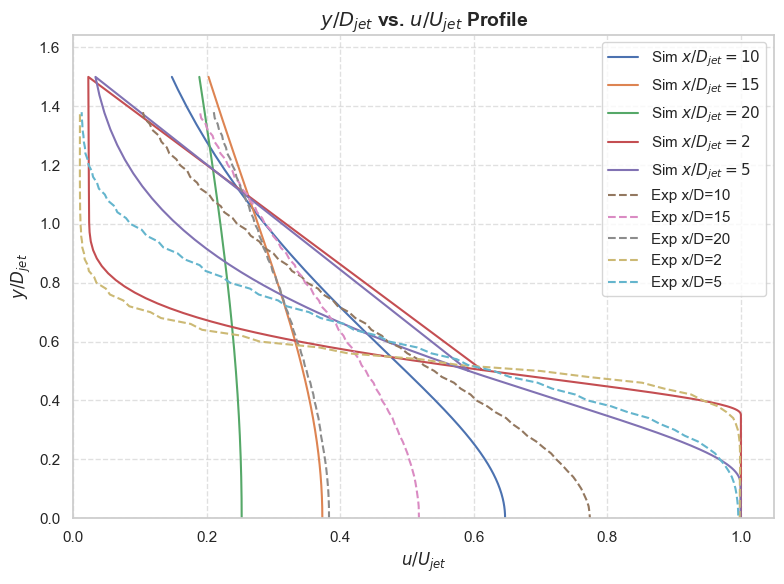

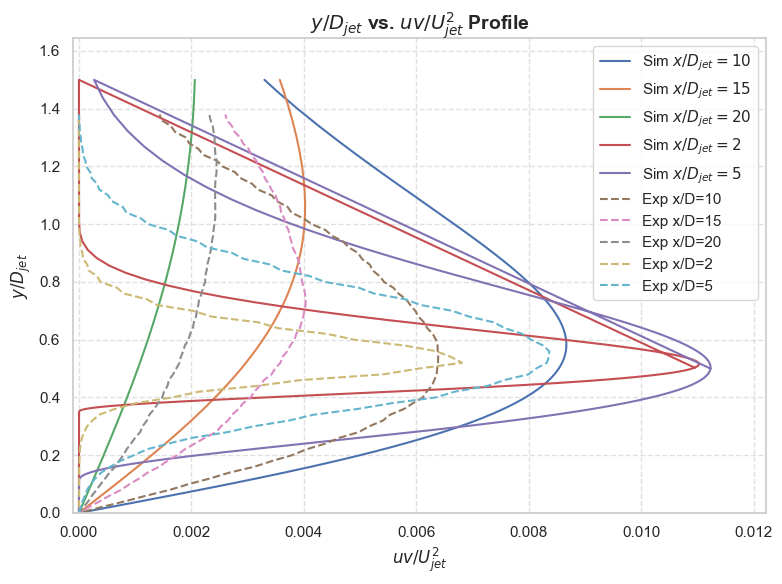

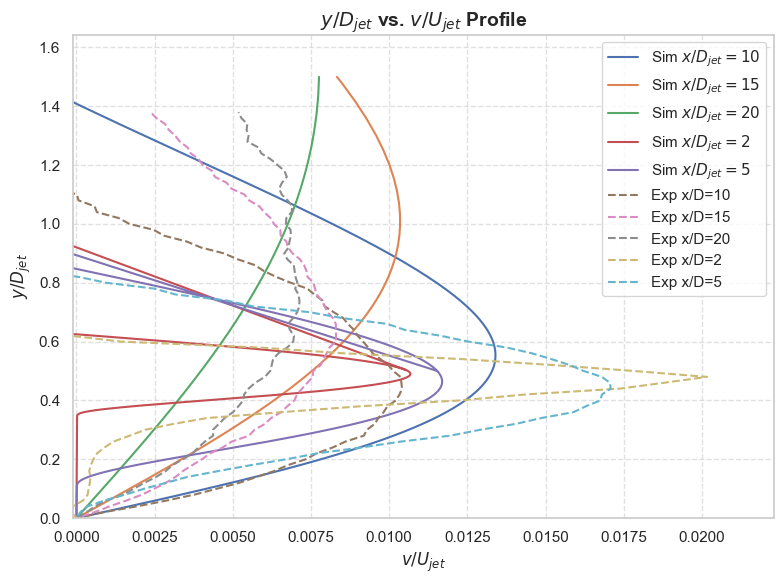

'<3'

In [53]:

reading_jet_file_nasa(
    FILE="exercise9/sa-turb5-y-over-d-jet-u-over-u-jet",
    xlabel=r'$u/U_{jet}$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $u/U_{jet}$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="u/Uj",
    nasa_style={"marker": "None", "linestyle": "--"}
)

reading_jet_file_nasa(
    FILE="exercise9/sa-turb5-y-over-d-jet-uv-over-u-jet2.xy",
    xlabel=r'$uv/U_{jet}^2$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $uv/U_{jet}^2$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="u'v'/Uj^2",
    nasa_style={"marker": "None", "linestyle": "--"}
)


reading_jet_file_nasa(
    FILE="exercise9/sa-turb5-y-over-d-jet-v-over-u-jet.xy",
    xlabel=r'$v/U_{jet}$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $v/U_{jet}$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="v/Uj",
    nasa_style={"marker": "None", "linestyle": "--"}
)


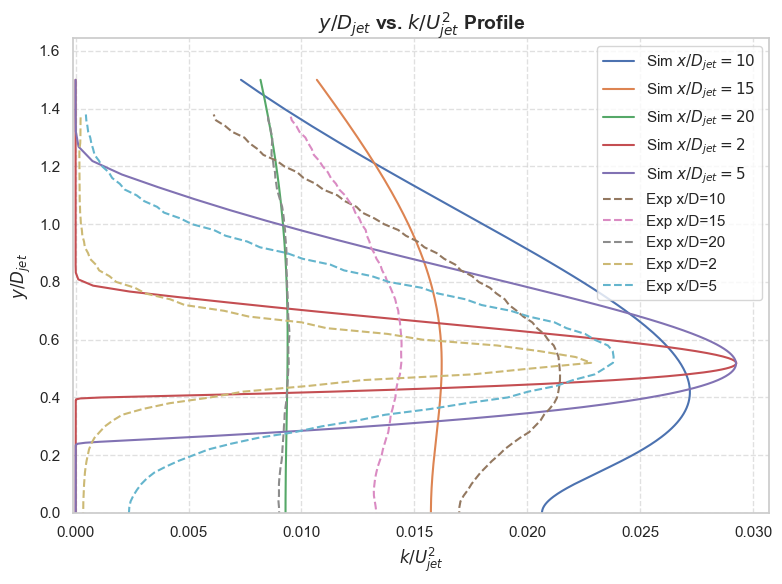

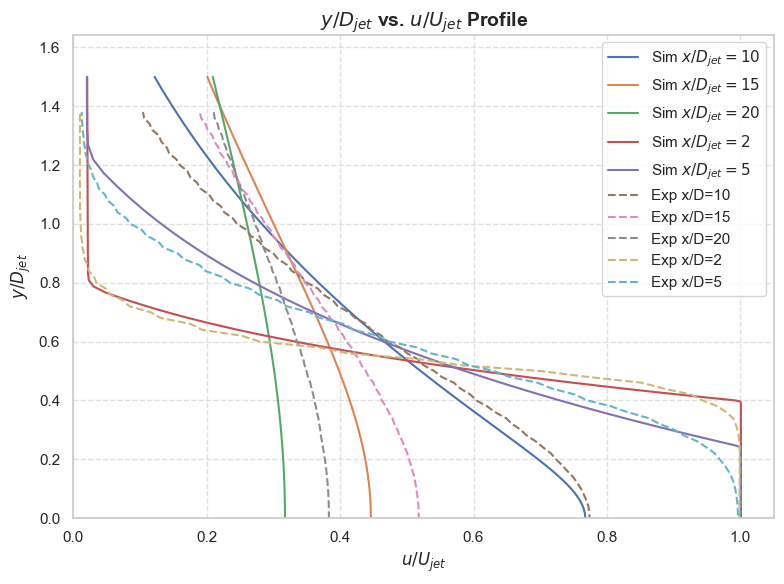

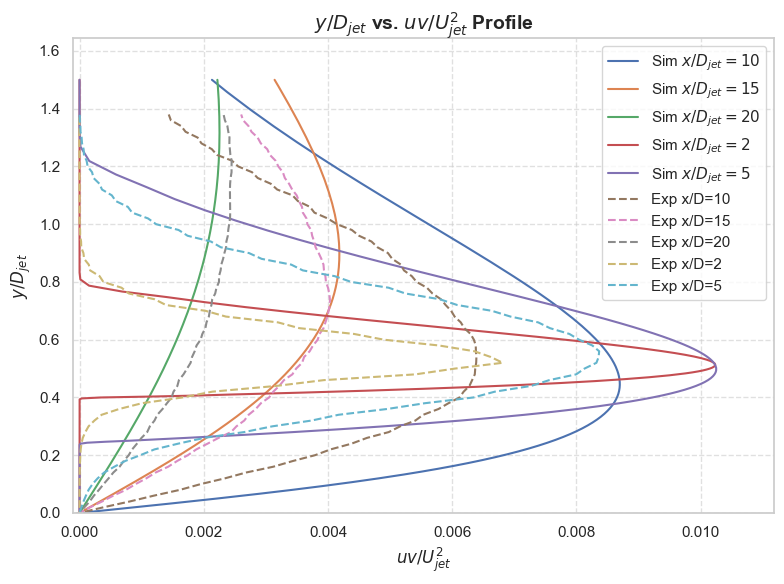

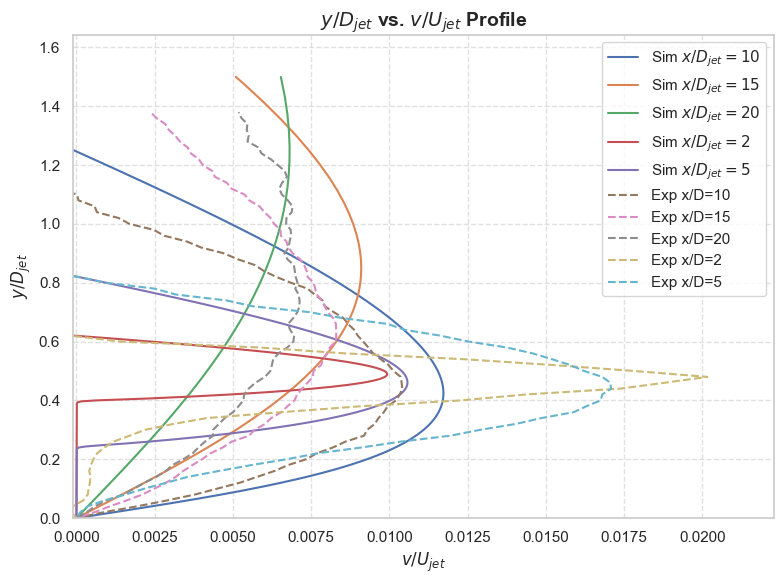

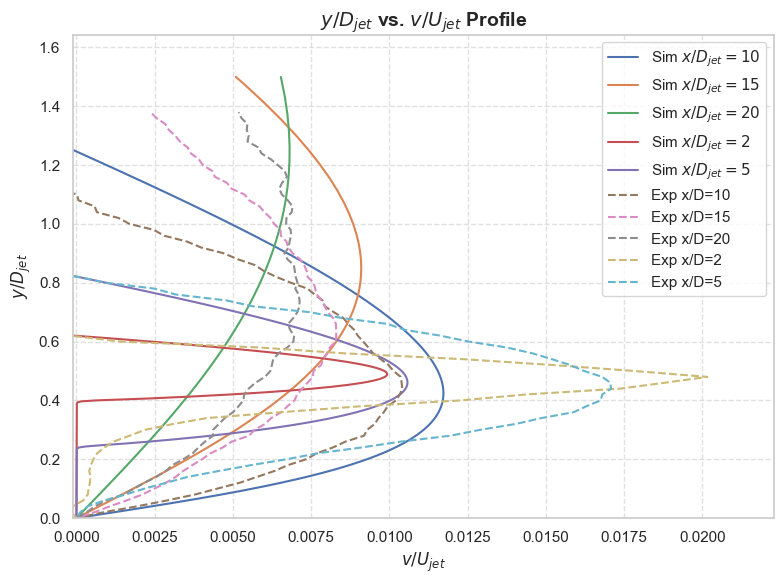

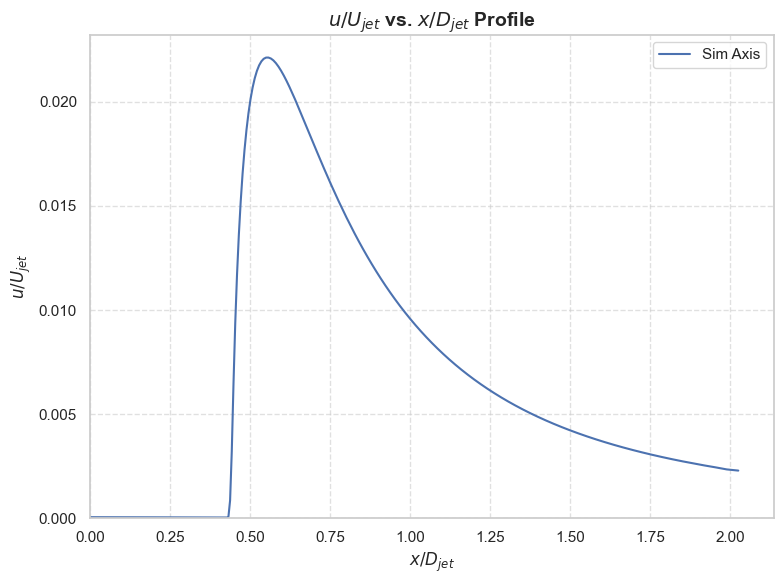

'<3'

In [54]:
def reading_jet_file_nasa(
    FILE,
    xlabel=None,
    ylabel=None,
    title=None,
    legend_labels=None,
    style_kwargs=None,
    data_nasa=None,  # Pass your experimental dataframe here
    nasa_quantity_y=None,  # e.g., "k/Uj^2"
    nasa_quantity_x=None,
    nasa_style=None,  # e.g., {"marker": "s", "linestyle": "None"}
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import re

    # === READ SIMULATION DATA ===
    with open(FILE, "r") as f:
        content = f.read()

    labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
    if labels_match:
        label1, label2 = labels_match.groups()
    else:
        raise ValueError("Could not find labels.")

    xlabel = xlabel or label1
    ylabel = ylabel or label2
    title = title or f"{ylabel} vs. {xlabel}"

    blocks = re.findall(
        r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
        content
    )

    dfs = []
    keys = []
    for key, data_block in blocks:
        keys.append(key)
        data = [
            list(map(float, line.strip().split()))
            for line in data_block.strip().splitlines()
            if line.strip()
        ]
        df = pd.DataFrame(data, columns=[f"{label1}_{key}", f"{label2}_{key}"])
        dfs.append(df)

    final_df = pd.concat(dfs, axis=1)

    # === PLOTTING ===
    plt.figure(figsize=(8, 6))
    
    # Plot simulation data
    for i, df in enumerate(dfs):
        x_col = df.columns[0]
        y_col = df.columns[1]
        label = legend_labels[i] if legend_labels and i < len(legend_labels) else y_col

        if style_kwargs:
            plt.plot(df[x_col], df[y_col], label=f"Sim {label}", **style_kwargs)
        else:
            plt.plot(df[x_col], df[y_col], label=f"Sim {label}")

    # Plot experimental NASA data
    if data_nasa is not None and nasa_quantity_x and nasa_quantity_y is not None:
        for x_loc in [10, 15, 20, 2, 5]:  # You can change these as needed
            x_col = f"{nasa_quantity_x}_x{x_loc}"
            y_col = f"{nasa_quantity_y}_x{x_loc}"
            if x_col in data_nasa.columns and y_col in data_nasa.columns:
                plt.plot(
                    data_nasa[x_col],
                    data_nasa[y_col],
                    label=f"Exp x/D={x_loc}",
                    **(nasa_style if nasa_style else {"marker": None, "linestyle": "--"})
                )

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(left=-0.0001)  # Set x-axis limit to start from 0
    plt.ylim(bottom=0)  # Set y-axis limit to start from 0
    plt.legend()
    plt.tight_layout()
    plt.show()

    return '<3'


def reading_jet_file_nasa_axis(
    FILE,
    xlabel=None,
    ylabel=None,
    title=None,
    legend_labels=None,
    style_kwargs=None,
    data_nasa=None,  # Pass your experimental dataframe here
    nasa_quantity_y=None,  # e.g., "k/Uj^2"
    nasa_quantity_x=None,
    nasa_style=None,  # e.g., {"marker": "s", "linestyle": "None"}
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import re

    # === READ SIMULATION DATA ===
    with open(FILE, "r") as f:
        content = f.read()

    labels_match = re.search(r'\(labels\s+"([^"]+)"\s+"([^"]+)"\)', content)
    if labels_match:
        label1, label2 = labels_match.groups()
    else:
        raise ValueError("Could not find labels.")

    xlabel = xlabel or label1
    ylabel = ylabel or label2
    title = title or f"{ylabel} vs. {xlabel}"

    blocks = re.findall(
        r'\(xy/key/label\s+"([^"]+)"\)\s*((?:-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s+-?\d*\.?\d+(?:[eE][\+\-]?\d+)?\s*\n?)+)',
        content
    )

    dfs = []
    keys = []
    for key, data_block in blocks:
        keys.append(key)
        data = [
            list(map(float, line.strip().split()))
            for line in data_block.strip().splitlines()
            if line.strip()
        ]
        df = pd.DataFrame(data, columns=[f"{label1}_{key}", f"{label2}_{key}"])
        dfs.append(df)

    final_df = pd.concat(dfs, axis=1)

    # === PLOTTING ===
    plt.figure(figsize=(8, 6))
    
    # Plot simulation data
    for i, df in enumerate(dfs):
        x_col = df.columns[0]
        y_col = df.columns[1]
        label = legend_labels[i] if legend_labels and i < len(legend_labels) else y_col

        if style_kwargs:
            plt.plot(df[x_col], df[y_col], label=f"Sim {label}", **style_kwargs)
        else:
            plt.plot(df[x_col], df[y_col], label=f"Sim {label}")

    # Plot experimental NASA data
    if data_nasa is not None and nasa_quantity_x and nasa_quantity_y is not None:
        for x_loc in [None]:  # You can change these as needed
            x_col = f"{nasa_quantity_x}_{x_loc}"
            y_col = f"{nasa_quantity_y}_{x_loc}"
            if x_col in data_nasa.columns and y_col in data_nasa.columns:
                plt.plot(
                    data_nasa[x_col],
                    data_nasa[y_col],
                    label=f"Exp {x_loc}",
                    **(nasa_style if nasa_style else {"marker": None, "linestyle": "--"})
                )

    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(left=-0.0001)  # Set x-axis limit to start from 0
    plt.ylim(bottom=0)  # Set y-axis limit to start from 0
    plt.legend()
    plt.tight_layout()
    plt.show()

    return '<3'

reading_jet_file_nasa(
    FILE="exercise9/turb1-y-over-d-jet-k-over-u-jet2.xy",
    xlabel=r'$k/U_{jet}^2$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $k/U_{jet}^2$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="k/Uj^2",
    nasa_style={"marker": "None", "linestyle": "--"}
)	

reading_jet_file_nasa(
    FILE="exercise9/turb1-y-over-d-jet-u-over-u-jet.xy",
    xlabel=r'$u/U_{jet}$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $u/U_{jet}$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="u/Uj",
    nasa_style={"marker": "None", "linestyle": "--"}
)

reading_jet_file_nasa(
    FILE="exercise9/turb1-y-over-d-jet-uv-over-u-jet2.xy",
    xlabel=r'$uv/U_{jet}^2$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $uv/U_{jet}^2$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="u'v'/Uj^2",
    nasa_style={"marker": "None", "linestyle": "--"}
)

reading_jet_file_nasa(
    FILE="exercise9/turb1-y-over-d-jet-v-over-u-jet.xy",
    xlabel=r'$v/U_{jet}$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $v/U_{jet}$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="v/Uj",
    nasa_style={"marker": "None", "linestyle": "--"}
)



reading_jet_file_nasa(
    FILE="exercise9/turb1-y-over-d-jet-v-over-u-jet.xy",
    xlabel=r'$v/U_{jet}$',
    ylabel=r'$y/D_{jet}$',
    title=r'$y/D_{jet}$ vs. $v/U_{jet}$ Profile',
    legend_labels=[r'$x/D_{jet}=10$', r'$x/D_{jet}=15$', r'$x/D_{jet}=20$', r'$x/D_{jet}=2$', r'$x/D_{jet}=5$'],
    data_nasa=df_nasa,
    nasa_quantity_y='y/Dj',
    nasa_quantity_x="v/Uj",
    nasa_style={"marker": "None", "linestyle": "--"}
)



#changed data-frame

reading_jet_file_nasa_axis(
    FILE="exercise9/turb5-k-over-u-jet2-over-x-over-d-jet.xy",
    xlabel=r'$x/D_{jet}$',
    ylabel=r'$u/U_{jet}$',
    title=r'$u/U_{jet}$ vs. $x/D_{jet}$ Profile',
    legend_labels=[r'Axis'],
    data_nasa=None,
    nasa_quantity_y='u/Uj',
    nasa_quantity_x="x/Dj",
    nasa_style={"marker": "None", "linestyle": "--"}
)

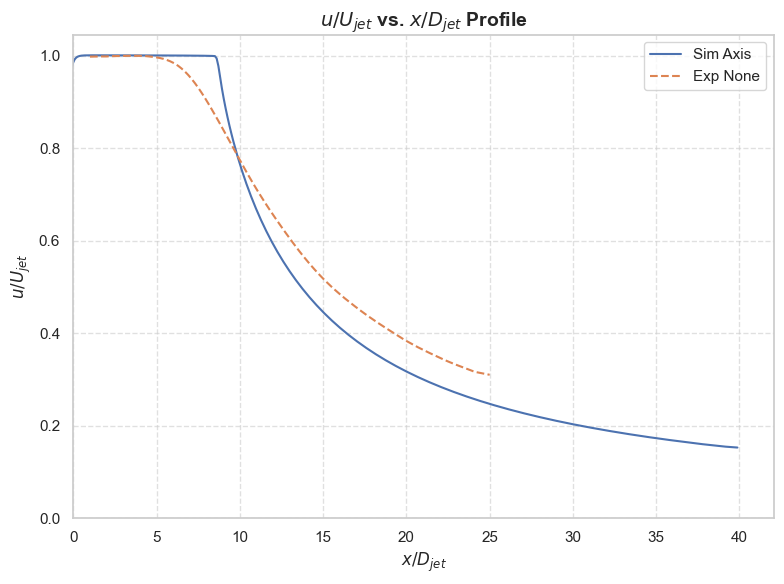

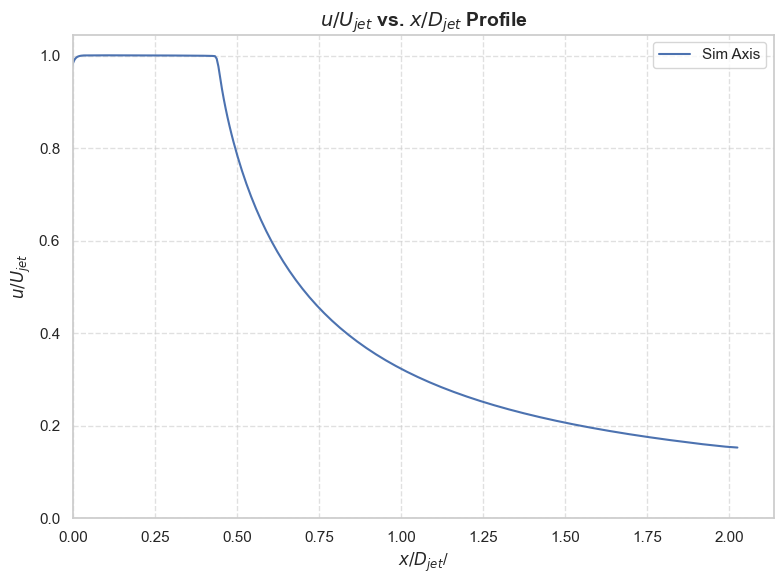

'<3'

In [55]:
reading_jet_file_nasa_axis(
    FILE="exercise9/turb5-u-over-u-jet-over-x-over-d-jet1.xy",
    xlabel=r'$x/D_{jet}$',
    ylabel=r'$u/U_{jet}$',
    title=r'$u/U_{jet}$ vs. $x/D_{jet}$ Profile',
    legend_labels=[r'Axis'],
    data_nasa=df_nasa_axis,
    nasa_quantity_y='u/Uj',
    nasa_quantity_x="x/Dj",
    nasa_style={"marker": "None", "linestyle": "--"}
)
reading_jet_file_nasa_axis(
    FILE="exercise9/turb5-u-over-u-jet-over-x-over-d-jet.xy",
    xlabel=r'$x/D_{jet}$/',
    ylabel=r'$u/U_{jet}$',
    title=r'$u/U_{jet}$ vs. $x/D_{jet}$ Profile',
    legend_labels=[r'Axis'],
    data_nasa=None,
    nasa_quantity_y='u/Uj',
    nasa_quantity_x="x/Dj",
    nasa_style={"marker": "None", "linestyle": "--"}
)